# Phoneme Decoding Pipeline — Step-by-Step Walkthrough

This notebook walks through the LDA-based phoneme-decoding pipeline on one patient (P22),
one sentence, end-to-end. Each cell shows one stage:

1. **Raw EEG** — the input signal
2. **Band-pass to high-gamma (70–170 Hz)** — isolate the band that reflects firing
3. **Envelope** — Hilbert magnitude, then low-pass to phoneme rate (~10 Hz)
4. **Window-sample to 200 fps** — coarsen the time axis to manageable frame rate
5. **Stack frames** — give each frame ±5 frames of temporal context
6. **Average within phoneme** (training only — uses MFA borders)
7. **Train LDA-shrinkage** — one labeled feature vector per training phoneme
8. **Inference at test time** — per-frame log-probabilities, smoothing, Viterbi, speech gate
9. **Score and visualize** — match predicted vs. gold phoneme sequences

In [2]:
import os, numpy as np, matplotlib.pyplot as plt
from collections import Counter
from scipy.signal import butter, sosfiltfilt, iirfilter, hilbert
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

from config import DUTCH_30_PATH
from run_pipeline import load_mfa_alignments
from extract_features import stackFeatures

# Pipeline already exists from your main notebook; if not:
# from dutch_30_pipeline import Dutch30Pipeline
# pipeline = Dutch30Pipeline(...).step1_load(...).step2_split(...)

PID         = 'P22'
EEG_SR      = 1024
WIN_S       = 0.015
SHIFT_S     = 0.005
WIN_SAMP    = int(EEG_SR * WIN_S)
SHIFT_SAMP  = int(EEG_SR * SHIFT_S)
MO, SS      = 5, 1            # stacking: ±5 frames, step 1
MARGIN      = MO * SS

print(f"Frame rate: {1/SHIFT_S:.0f} fps  (one frame every {SHIFT_S*1000:.0f} ms)")
print(f"Stacking: {2*MO+1} consecutive frames per stacked vector  "
      f"(spans {(2*MO+1)*SHIFT_S*1000:.0f} ms)")

Running from clean repo, using data from: C:\mozg\code\SingleWordProductionDutch
Frame rate: 200 fps  (one frame every 5 ms)
Stacking: 11 consecutive frames per stacked vector  (spans 55 ms)


## Step 1 — Load raw EEG and pick one sentence

iEEG is recorded at 1024 Hz across ~110 channels (electrodes implanted on the cortical
surface). Each "sentence" is a slice of this continuous recording, bracketed by the
moment the patient started and stopped speaking.

In [5]:
# build pipeline
import os, numpy as np, warnings
from collections import defaultdict, Counter
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from dataset_config import Dutch30Config
from config import DUTCH_30_PATH
from run_pipeline import load_mfa_alignments
from extract_features import extractHG, stackFeatures

config = Dutch30Config()
extractor = Dutch30FeatureExtractor(config=config)
pipeline = Dutch30Pipeline(extractor, config=config, use_wav2vec=False)
pipeline.step1_load_dutch30_data(patient_range=(21, 30))
pipeline.step2_split_by_instances(train_fraction=0.8)
pipeline.step3_load_channel_exclusions('channel_exclusions.json')
pipeline.apply_channel_exclusions()

Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=100, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, groups=False

Full recording:   614,832 samples × 114 channels  = 10.0 min at 1024 Hz

Sentence #0: "Volgens mij werkt Skype niet meer."
  EEG slice: 5,127 samples = 5.01 s
  MFA phonemes: 26
  Example phonemes (first 5): [('v', 1.03, 1.17), ('ɔ', 1.17, 1.22), ('l', 1.22, 1.3), ('ɣ', 1.3, 1.36), ('ɛ', 1.36, 1.41)]


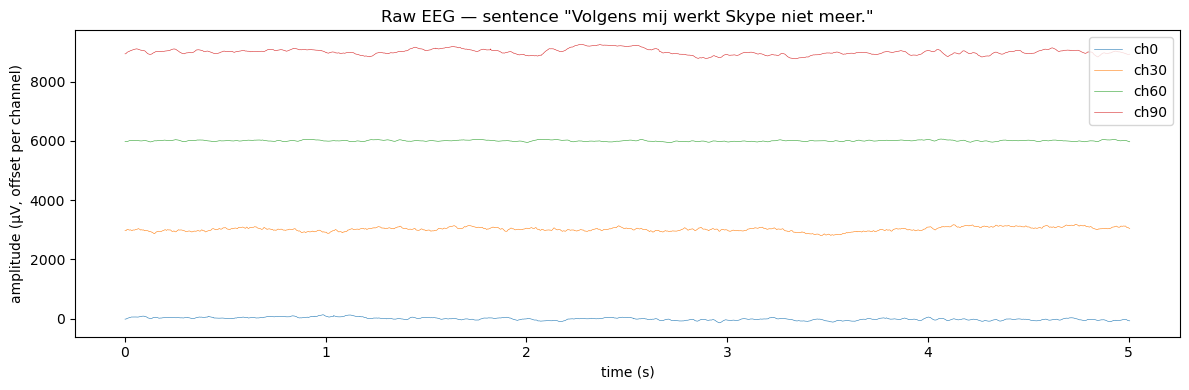

In [6]:
raw_eeg = np.load(os.path.join(DUTCH_30_PATH, 'raw', f'{PID}_sEEG.npy'))
if raw_eeg.ndim == 2 and raw_eeg.shape[0] < raw_eeg.shape[1]:
    raw_eeg = raw_eeg.T
print(f"Full recording: {raw_eeg.shape[0]:>9,} samples × {raw_eeg.shape[1]} channels  "
      f"= {raw_eeg.shape[0] / EEG_SR / 60:.1f} min at {EEG_SR} Hz")

# Pick one sentence
wd  = pipeline.split_result['word_segments_dict'][PID]
mfa = load_mfa_alignments(PID)
all_real = [i for i, s in enumerate(wd['sentence_list'])
            if isinstance(s, dict) and s.get('text') and i in mfa]
SENT_IDX = all_real[0]    # first sentence with text + MFA
s0, s1   = wd['sentence_list'][SENT_IDX]['stim_start_idx'], \
           wd['sentence_list'][SENT_IDX]['stim_end_idx']
raw_slice = raw_eeg[s0:s1]

print(f"\nSentence #{SENT_IDX}: \"{wd['sentence_list'][SENT_IDX]['text']}\"")
print(f"  EEG slice: {raw_slice.shape[0]:,} samples = {raw_slice.shape[0]/EEG_SR:.2f} s")
print(f"  MFA phonemes: {len(mfa[SENT_IDX])}")
print(f"  Example phonemes (first 5): "
      f"{[(p['phone'], round(p['start_s'], 3), round(p['end_s'], 3)) for p in mfa[SENT_IDX][:5]]}")

fig, ax = plt.subplots(figsize=(12, 4))
t = np.arange(raw_slice.shape[0]) / EEG_SR
for ch in [0, 30, 60, 90]:
    ax.plot(t, raw_slice[:, ch] + ch*100, lw=0.4, label=f'ch{ch}')
ax.set_xlabel('time (s)'); ax.set_ylabel('amplitude (µV, offset per channel)')
ax.set_title(f'Raw EEG — sentence "{wd["sentence_list"][SENT_IDX]["text"]}"')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

## Step 2 — Band-pass to high-gamma (70–170 Hz)

High-gamma activity is the cortical signal that reflects local neural firing.
We isolate it with a 4th-order Butterworth band-pass (zero-phase, applied
forward+backward via `sosfiltfilt`), plus notch filters at 50 and 150 Hz to
suppress mains noise and its harmonic.

The result still looks like fast noise — what we want is the *envelope* of this
filtered signal, which we'll extract in the next step.

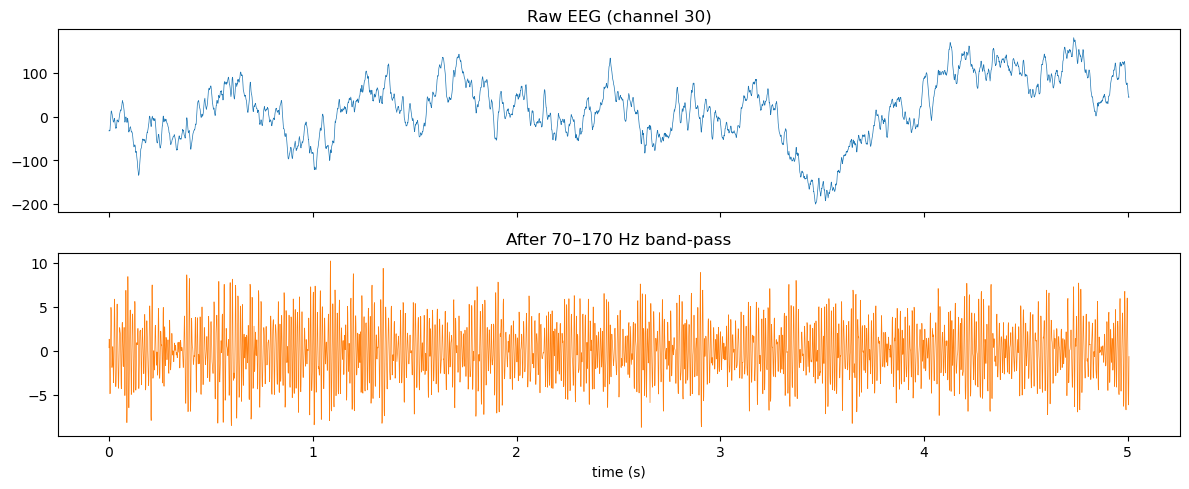

In [7]:
# 50/150 Hz notches (mains + first harmonic)
def make_notch(f0, fs, Q=30):
    bw = f0 / Q
    sos = iirfilter(2, [f0 - bw/2, f0 + bw/2], btype='bandstop',
                    fs=fs, output='sos')
    return sos

sos_notch_50  = make_notch(50,  EEG_SR)
sos_notch_150 = make_notch(150, EEG_SR)
sos_hg        = butter(4, [70, 170], btype='bandpass', fs=EEG_SR, output='sos')

x = raw_slice.copy()
x = sosfiltfilt(sos_notch_50, x, axis=0)
x = sosfiltfilt(sos_notch_150, x, axis=0)
x_bp = sosfiltfilt(sos_hg, x, axis=0)

ch = 30   # pick one channel to visualize
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t, raw_slice[:, ch], lw=0.5);       axes[0].set_title(f'Raw EEG (channel {ch})')
axes[1].plot(t, x_bp[:, ch], color='C1', lw=0.5); axes[1].set_title('After 70–170 Hz band-pass')
axes[1].set_xlabel('time (s)')
plt.tight_layout(); plt.show()

## Step 3 — Hilbert envelope, low-pass at 12 Hz

The band-pass output still oscillates at ~100 Hz. What we actually want is the
*amplitude* of this oscillation — how much HG activity is present at each
moment. The Hilbert transform's magnitude gives us this envelope.

After taking the envelope, we smooth it with a 12 Hz Butterworth low-pass. The
phoneme rate is 5–10 Hz, so 12 Hz preserves phoneme-rate modulation while
suppressing higher-frequency envelope jitter.

Final compression: `log1p` to make the distribution more Gaussian (LDA likes
Gaussian-ish features).

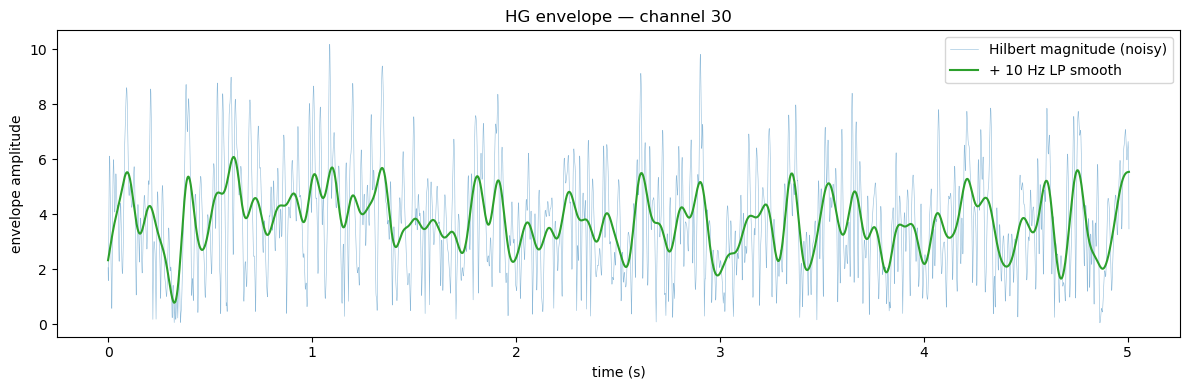

In [9]:
sos_lp = butter(4, 10.0, btype='lowpass', fs=EEG_SR, output='sos')

env_raw     = np.abs(hilbert(x_bp, axis=0))           # raw envelope
env_smooth  = sosfiltfilt(sos_lp, env_raw, axis=0)    # 12 Hz LP
env_smooth  = np.maximum(env_smooth, 0)               # clamp filter ringing

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, env_raw[:, ch],    lw=0.4, alpha=0.5, label='Hilbert magnitude (noisy)')
ax.plot(t, env_smooth[:, ch], lw=1.5, color='C2', label='+ 10 Hz LP smooth')
ax.set_xlabel('time (s)'); ax.set_ylabel('envelope amplitude')
ax.set_title(f'HG envelope — channel {ch}')
ax.legend(); plt.tight_layout(); plt.show()

## Step 4 — Sample to 200 fps and compress

At this point our envelope is still at 1024 Hz. We don't need that resolution —
phonemes are ~80 ms long, so 200 fps (5 ms per frame) is plenty. We take every
5th sample of the envelope.

Then `log1p` compression to make the distribution more Gaussian for LDA.

After frame sampling: 1026 frames × 114 channels  (was 5127 samples at 1024 Hz)


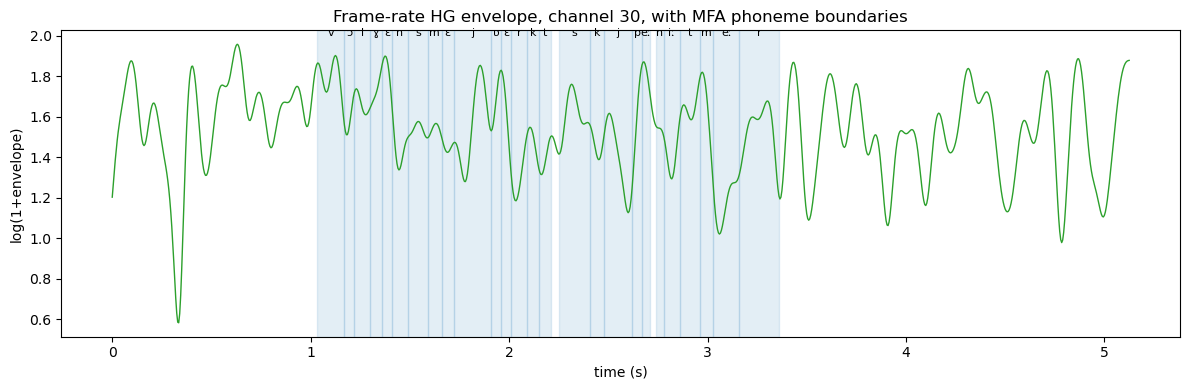

In [10]:
env_log = np.log1p(env_smooth[::SHIFT_SAMP].astype(np.float32))   # (T_frames, n_ch)
T_ext   = env_log.shape[0]
print(f"After frame sampling: {T_ext} frames × {env_log.shape[1]} channels  "
      f"(was {raw_slice.shape[0]} samples at {EEG_SR} Hz)")

t_frames = np.arange(T_ext) * SHIFT_S
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_frames, env_log[:, ch], lw=1.0, color='C2')
# overlay MFA phoneme boundaries
for ph in mfa[SENT_IDX]:
    ax.axvspan(ph['start_s'], ph['end_s'], alpha=0.12, color='C0')
    ax.text((ph['start_s']+ph['end_s'])/2, env_log[:, ch].max()*1.02,
            ph['phone'], ha='center', fontsize=8)
ax.set_xlabel('time (s)'); ax.set_ylabel('log(1+envelope)')
ax.set_title(f'Frame-rate HG envelope, channel {ch}, with MFA phoneme boundaries')
plt.tight_layout(); plt.show()

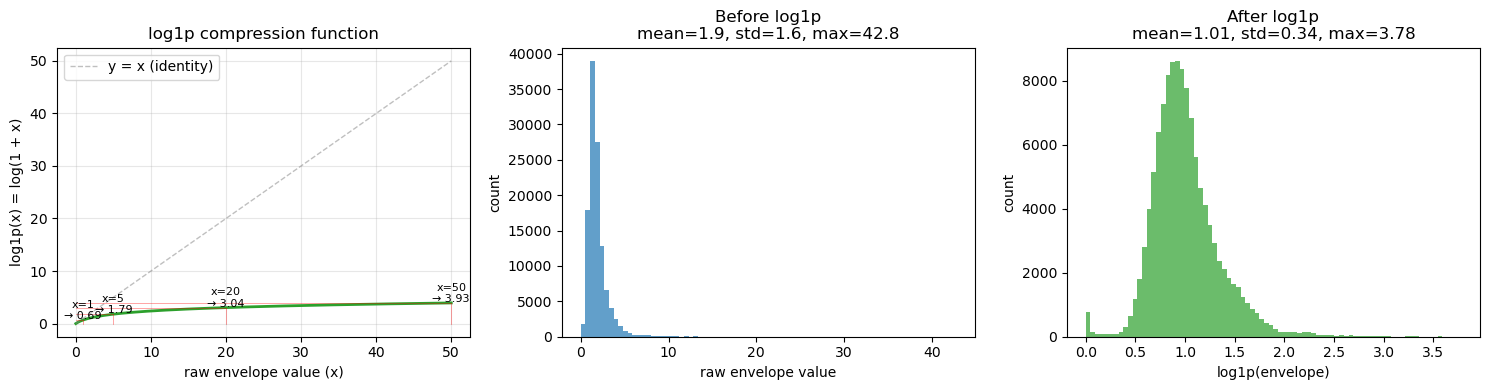

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# ── The function itself ─────────────────────────────────────────────
x_grid = np.linspace(0, 50, 500)
y_grid = np.log1p(x_grid)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: The function shape
ax = axes[0]
ax.plot(x_grid, y_grid, lw=2, color='C2')
ax.plot(x_grid, x_grid, ls='--', lw=1, color='gray', alpha=0.5, label='y = x (identity)')
# Annotate compression effect
for xv in [1, 5, 20, 50]:
    yv = np.log1p(xv)
    ax.plot([xv, xv], [0, yv], color='red', lw=0.5, alpha=0.5)
    ax.plot([0, xv], [yv, yv], color='red', lw=0.5, alpha=0.5)
    ax.text(xv, yv + 0.15, f'x={xv}\n→ {yv:.2f}', fontsize=8, ha='center')
ax.set_xlabel('raw envelope value (x)')
ax.set_ylabel('log1p(x) = log(1 + x)')
ax.set_title('log1p compression function')
ax.legend(); ax.grid(alpha=0.3)

# Plot 2: Histogram of RAW envelope values (one sentence, all channels)
ax = axes[1]
raw_vals = env_smooth[::SHIFT_SAMP].flatten()
ax.hist(raw_vals, bins=80, color='C0', alpha=0.7)
ax.set_xlabel('raw envelope value')
ax.set_ylabel('count')
ax.set_title(f'Before log1p\nmean={raw_vals.mean():.1f}, '
             f'std={raw_vals.std():.1f}, max={raw_vals.max():.1f}')

# Plot 3: Histogram of log1p-transformed values
ax = axes[2]
log_vals = np.log1p(raw_vals)
ax.hist(log_vals, bins=80, color='C2', alpha=0.7)
ax.set_xlabel('log1p(envelope)')
ax.set_ylabel('count')
ax.set_title(f'After log1p\nmean={log_vals.mean():.2f}, '
             f'std={log_vals.std():.2f}, max={log_vals.max():.2f}')

plt.tight_layout(); plt.show()

## Step 5 — Stack frames for temporal context

LDA classifies frame by frame, but neural signal at one frame alone isn't
enough — we want each frame's feature vector to also know about its neighbors.
We **stack** each frame with the 5 frames before and after it (11 frames total),
giving each "stacked frame" 11× the per-frame dimensions.

In [11]:
stk = stackFeatures(env_log, modelOrder=MO, stepSize=SS)
print(f"Stacked: ({T_ext} frames × {env_log.shape[1]} channels) "
      f"→ ({stk.shape[0]} stacked frames × {stk.shape[1]} features)")
print(f"  (lost {T_ext - stk.shape[0]} edge frames = MARGIN×2 = {2*MARGIN})")
print(f"  Each stacked vector = {2*MO+1} frames × {env_log.shape[1]} channels = "
      f"{(2*MO+1) * env_log.shape[1]} dims")

Stacked: (1026 frames × 114 channels) → (1016 stacked frames × 1254 features)
  (lost 10 edge frames = MARGIN×2 = 10)
  Each stacked vector = 11 frames × 114 channels = 1254 dims


## Step 6 — Build training set: one labeled vector per MFA phoneme

For training, MFA tells us the start and end time of each phoneme. We extract
the stacked frames inside each phoneme's borders, **average** them, and label
the result with the phoneme symbol. This gives us one feature vector per
phoneme — much cleaner than per-frame because averaging suppresses noise.

We'll demonstrate this on the first sentence, then do it across a handful of
training sentences for the LDA fit.

In [12]:
def averaged_features_for_sentence(stk, mfa_phones, margin=MARGIN):
    feats, labels = [], []
    T = stk.shape[0]
    for ph in mfa_phones:
        k_s = int(np.ceil((ph['start_s']*EEG_SR - WIN_SAMP/2) / SHIFT_SAMP))
        k_e = int(np.floor((ph['end_s']  *EEG_SR - WIN_SAMP/2) / SHIFT_SAMP))
        ks  = max(0, k_s - margin); ke = min(T - 1, k_e - margin)
        if ke < ks: continue
        feats.append(stk[ks:ke+1].mean(axis=0))
        labels.append(ph['phone'])
    return np.array(feats), np.array(labels)

X_demo, y_demo = averaged_features_for_sentence(stk, mfa[SENT_IDX])
print(f"Sentence {SENT_IDX}: {len(X_demo)} averaged-feature vectors, "
      f"each with {X_demo.shape[1]} dims")
print(f"Phoneme labels: {y_demo.tolist()}")

Sentence 0: 26 averaged-feature vectors, each with 1254 dims
Phoneme labels: ['v', 'ɔ', 'l', 'ɣ', 'ɛ', 'n', 's', 'm', 'ɛ', 'j', 'ʋ', 'ɛ', 'r', 'k', 't', 's', 'k', 'j', 'p', 'eː', 'n', 'iː', 't', 'm', 'eː', 'r']


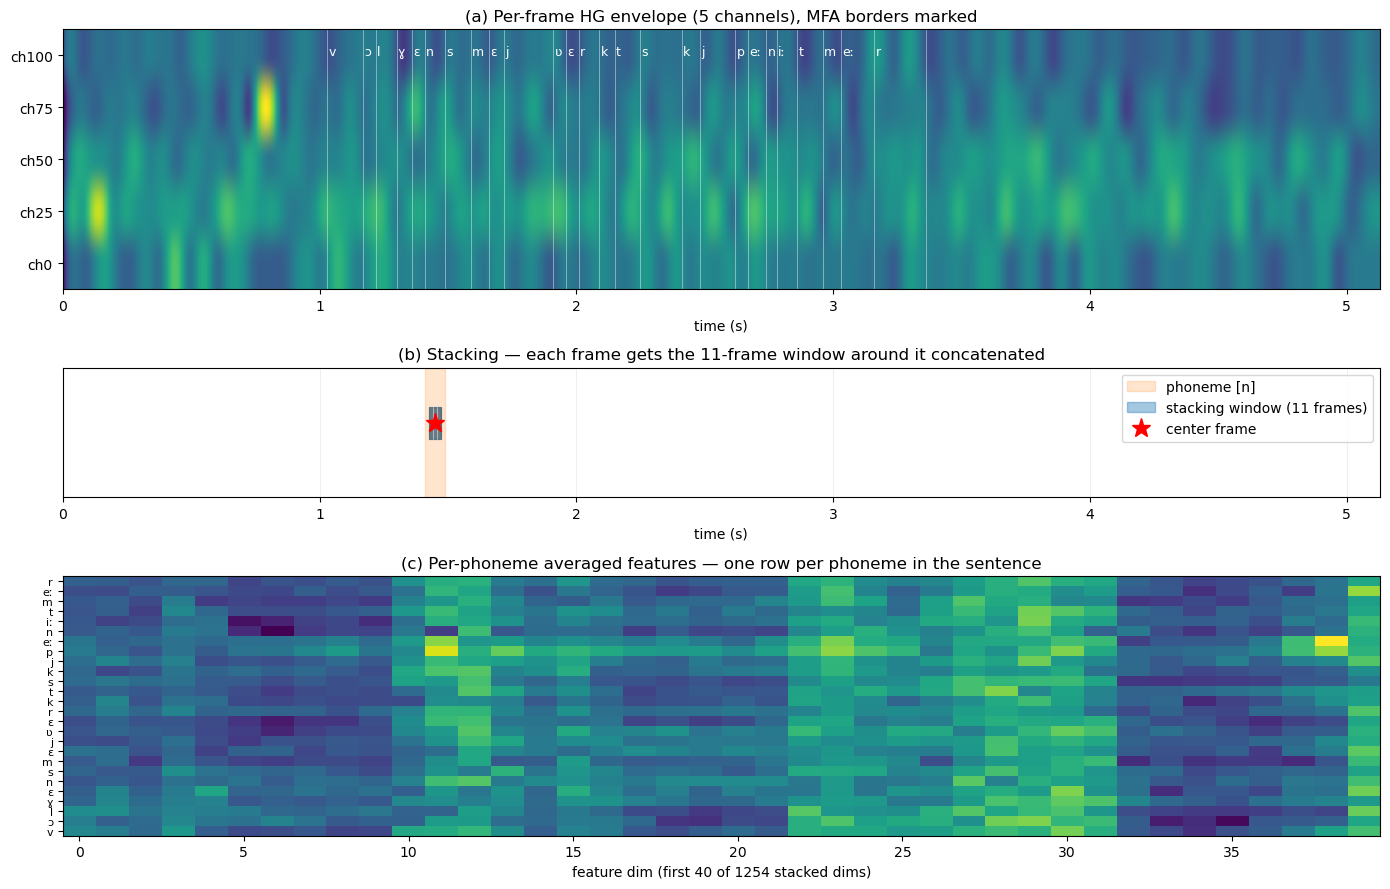

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Pick a few channels to show clearly (chosen for visible structure)
demo_chs = [0, 25, 50, 75, 100]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), gridspec_kw={'height_ratios':[2,1,2]})

# ── (a) Per-frame envelope heatmap with phoneme borders ────────────
ax = axes[0]
im = ax.imshow(env_log[:, demo_chs].T, aspect='auto', origin='lower',
                cmap='viridis',
                extent=[0, T_ext*SHIFT_S, 0, len(demo_chs)])
for ph in mfa[SENT_IDX]:
    ax.axvline(ph['start_s'], color='white', lw=0.6, alpha=0.5)
    ax.text(ph['start_s'] + 0.005, len(demo_chs)-0.3, ph['phone'],
            color='white', fontsize=9, va='top')
ax.axvline(mfa[SENT_IDX][-1]['end_s'], color='white', lw=0.6, alpha=0.5)
ax.set_yticks(np.arange(len(demo_chs)) + 0.5)
ax.set_yticklabels([f'ch{c}' for c in demo_chs])
ax.set_xlabel('time (s)'); ax.set_title('(a) Per-frame HG envelope (5 channels), MFA borders marked')

# ── (b) Stacking schematic: show 11-frame window for ONE example frame ─
ax = axes[1]
ax.set_xlim(0, T_ext * SHIFT_S); ax.set_ylim(-0.5, 1.5)
target_phoneme_idx = 5
ph = mfa[SENT_IDX][target_phoneme_idx]
center_frame = int((ph['start_s'] + ph['end_s']) / 2 / SHIFT_S)
ax.axvspan(ph['start_s'], ph['end_s'], color='C1', alpha=0.2, label=f'phoneme [{ph["phone"]}]')
# Show 11-frame stacking window centered at this frame
win_t0 = (center_frame - MO) * SHIFT_S
win_t1 = (center_frame + MO) * SHIFT_S
ax.add_patch(patches.Rectangle((win_t0, 0.4), win_t1 - win_t0, 0.5,
                                facecolor='C0', alpha=0.4, edgecolor='C0',
                                label=f'stacking window ({2*MO+1} frames)'))
for k in range(-MO, MO+1):
    t = (center_frame + k) * SHIFT_S
    ax.plot([t, t], [0.4, 0.9], 'k-', lw=0.5, alpha=0.5)
ax.plot([center_frame*SHIFT_S], [0.65], 'r*', ms=14, label='center frame')
ax.set_xlabel('time (s)'); ax.set_yticks([])
ax.set_title(f'(b) Stacking — each frame gets the {2*MO+1}-frame window around it concatenated')
ax.legend(loc='upper right'); ax.grid(alpha=0.2)

# ── (c) Per-phoneme averaged feature vectors (heatmap, phonemes × dims) ─
ax = axes[2]
# Show only first ~40 stacked dims for clarity (out of 11*n_ch)
n_show = min(40, X_demo.shape[1])
im = ax.imshow(X_demo[:, :n_show], aspect='auto', origin='lower',
                cmap='viridis')
ax.set_yticks(np.arange(len(y_demo)))
ax.set_yticklabels(y_demo, fontsize=8)
ax.set_xlabel(f'feature dim (first {n_show} of {X_demo.shape[1]} stacked dims)')
ax.set_title(f'(c) Per-phoneme averaged features — one row per phoneme in the sentence')
plt.tight_layout(); plt.show()

## Step 7 — Train LDA-shrinkage on multiple training sentences

We repeat Step 6 for a handful of training sentences, then fit one
LinearDiscriminantAnalysis classifier across all of them. Shrinkage='auto' uses
Ledoit-Wolf to estimate the covariance — essential when feature dim (~1200) is
comparable to sample count (~few hundred).

In [13]:
TRAIN_SENT_IDS = all_real[1:11]   # use sentences 1..10 as train, sentence 0 as test demo

def extract_envelope(eeg_slice):
    x = eeg_slice.copy()
    x = sosfiltfilt(sos_notch_50, x, axis=0)
    x = sosfiltfilt(sos_notch_150, x, axis=0)
    x_bp = sosfiltfilt(sos_hg, x, axis=0)
    env = np.abs(hilbert(x_bp, axis=0))
    env = sosfiltfilt(sos_lp, env, axis=0)
    env = np.maximum(env, 0)
    return np.log1p(env[::SHIFT_SAMP].astype(np.float32))

X_train, y_train = [], []
for sid in TRAIN_SENT_IDS:
    s = wd['sentence_list'][sid]; s0_, s1_ = s['stim_start_idx'], s['stim_end_idx']
    env_t = extract_envelope(raw_eeg[s0_:s1_])
    stk_t = stackFeatures(env_t, modelOrder=MO, stepSize=SS)
    Xf, yf = averaged_features_for_sentence(stk_t, mfa[sid])
    X_train.append(Xf); y_train.append(yf)
X_train = np.concatenate(X_train); y_train = np.concatenate(y_train)
print(f"Training set: {len(X_train)} phoneme samples × {X_train.shape[1]} features, "
      f"{len(set(y_train))} unique phonemes")

scaler = StandardScaler().fit(X_train)
clf    = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
clf.fit(scaler.transform(X_train), y_train)
print(f"LDA fitted. Classes: {clf.classes_.tolist()}")

Training set: 334 phoneme samples × 1254 features, 36 unique phonemes
LDA fitted. Classes: ['a', 'aː', 'b', 'c', 'd', 'eː', 'f', 'h', 'i', 'iː', 'j', 'k', 'l', 'm', 'n', 'oː', 'p', 'r', 's', 't', 'uː', 'v', 'w', 'x', 'yː', 'z', 'ŋ', 'œ', 'ɑ', 'ɔ', 'ɛ', 'ɣ', 'ɥ', 'ɪ', 'ʋ', 'ʏ']


## Step 8 — Inference on the test sentence

At test time we don't know phoneme boundaries. So we:

1. Compute per-frame log-probabilities for every class.
2. **Smooth** them along time with a moving average (W=31 frames ≈ 155 ms).
   This combats per-frame flicker — neighboring frames vote together.
3. **Viterbi-decode** with a self-loop bonus that prefers staying in the same
   class. The bonus is auto-tuned to match expected segment count; for this
   demo we'll use a fixed value of 5.
4. Collapse consecutive same-class frames into phoneme runs.

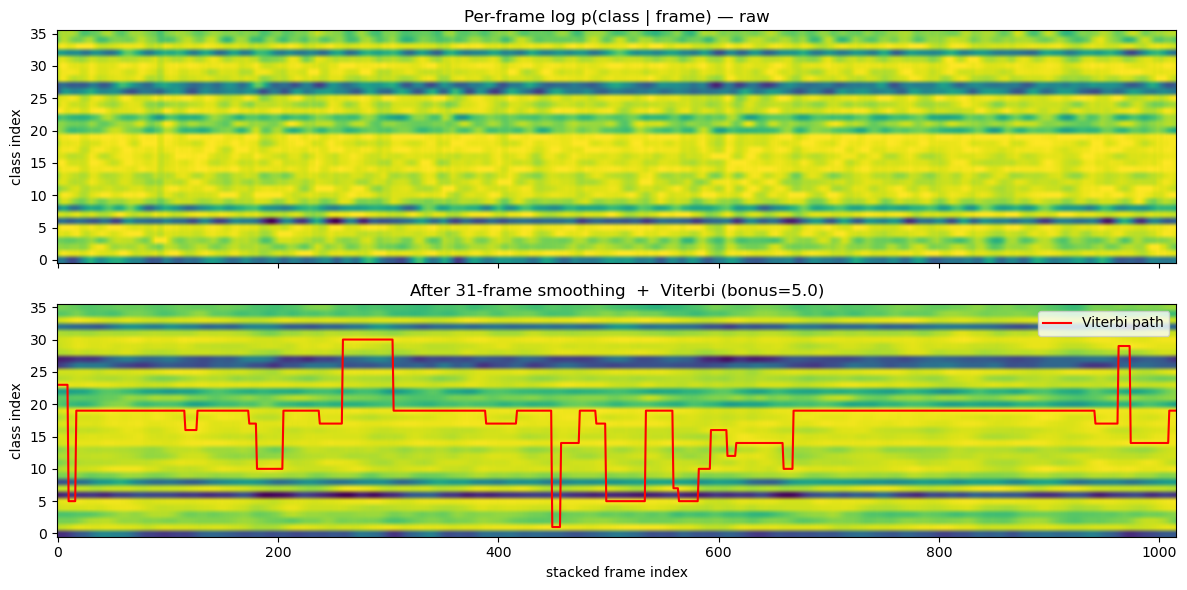

In [14]:
SMOOTH_LOGP_W   = 31
SELF_LOOP_BONUS = 5.0

def smooth_cols(logp, w):
    if w <= 1: return logp
    T, K = logp.shape
    pl = (w - 1) // 2; pr = w - 1 - pl
    padded = np.pad(logp, ((pl, pr), (0, 0)), mode='edge')
    csum = np.concatenate([np.zeros((1, K)), np.cumsum(padded, axis=0)])
    return (csum[w:] - csum[:-w]) / w

def viterbi_decode(logp, self_bonus):
    T, K = logp.shape
    delta = np.empty((T, K)); bptr = np.empty((T, K), dtype=np.int32)
    delta[0] = logp[0]; all_k = np.arange(K)
    for t in range(1, T):
        prev = delta[t-1]
        order = np.argsort(prev); idx1, idx2 = order[-1], order[-2]
        best_switch = np.full(K, prev[idx1]); best_switch[idx1] = prev[idx2]
        bptr_switch = np.full(K, idx1);       bptr_switch[idx1] = idx2
        stay = prev + self_bonus
        choose_stay = stay >= best_switch
        delta[t] = logp[t] + np.where(choose_stay, stay, best_switch)
        bptr[t]  = np.where(choose_stay, all_k, bptr_switch)
    path = np.empty(T, dtype=np.int32); path[-1] = delta[-1].argmax()
    for t in range(T-2, -1, -1): path[t] = bptr[t+1, path[t+1]]
    return path

# Test = our original sentence (note: in real pipeline use held-out sentences)
logp_raw    = clf.predict_log_proba(scaler.transform(stk))      # (T_stk, K)
logp_smooth = smooth_cols(logp_raw, SMOOTH_LOGP_W)
path        = viterbi_decode(logp_smooth, SELF_LOOP_BONUS)

# Show the log-prob heatmap before/after smoothing, and the Viterbi path on top
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].imshow(logp_raw.T,    aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Per-frame log p(class | frame) — raw')
axes[0].set_ylabel('class index')
axes[1].imshow(logp_smooth.T, aspect='auto', origin='lower', cmap='viridis')
axes[1].plot(np.arange(len(path)), path, color='red', lw=1.5,
             label='Viterbi path')
axes[1].set_title(f'After {SMOOTH_LOGP_W}-frame smoothing  +  Viterbi (bonus={SELF_LOOP_BONUS})')
axes[1].set_xlabel('stacked frame index'); axes[1].set_ylabel('class index')
axes[1].legend(loc='upper right')
plt.tight_layout(); plt.show()

## Step 9 — Speech onset detection and gating

The LDA classifier always predicts *some* phoneme at every frame — even during
pre-speech silence and inter-word gaps. We have no "silence" class in training
(MFA only labels the speech intervals), so the model just picks the closest-
looking phoneme for those moments. Those spurious predictions inflate the pred
count and dilute the matching signal.

A separately-trained **speech vs. non-speech detector** (BiLSTM operating on
stacked HG features) gives us a per-frame probability that the patient is
actively speaking. We threshold at 0.5 to get a binary speech mask, then drop
any predicted phoneme segment whose majority of frames falls outside the speech
window.

This produces dramatically cleaner predictions, and as a side effect lets
Viterbi use a smaller `self_bonus` (the gate now does the work of cleaning up
silence-region predictions, so the prior doesn't have to fight as hard).

Loaded speech detector. Trained patients: ['P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30']
Speech detector output: 1016 frames
  Speech (above 0.5): 572 frames (56.3%)
  Non-speech: 444 frames (43.7%)


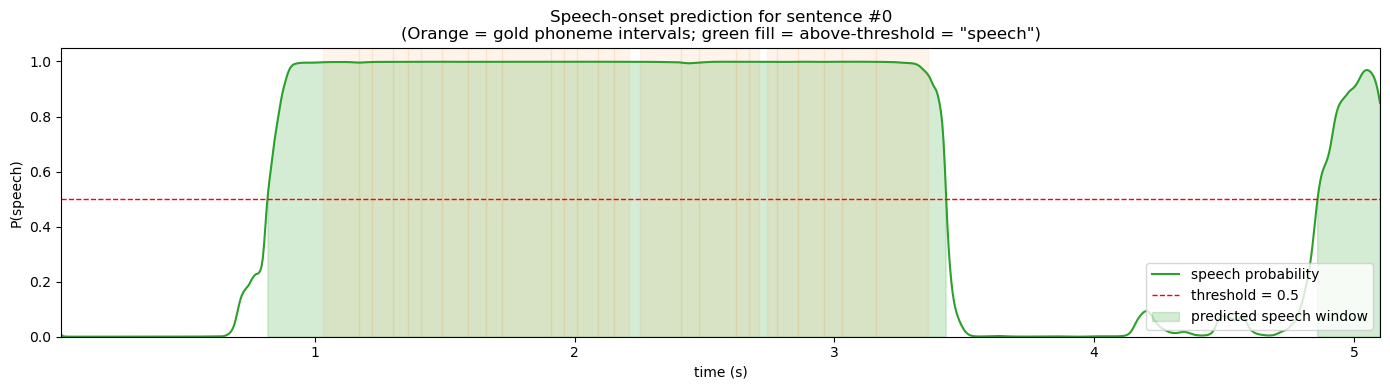

In [23]:
import torch, torch.nn as nn

# Architecture (matches the trained checkpoint format)
class CrossPatientSpeechDetector(nn.Module):
    def __init__(self, n_in_per_pid, embed_dim=128,
                 lstm_hidden=128, lstm_layers=2, dropout=0.2):
        super().__init__()
        self.projs = nn.ModuleDict({
            pid: nn.Sequential(nn.Linear(n_in, embed_dim), nn.GELU(),
                               nn.Dropout(dropout))
            for pid, n_in in n_in_per_pid.items()
        })
        self.lstm = nn.LSTM(embed_dim, lstm_hidden, num_layers=lstm_layers,
                            dropout=dropout if lstm_layers > 1 else 0.0,
                            bidirectional=True, batch_first=False)
        self.head = nn.Linear(lstm_hidden * 2, 2)
    def forward(self, x, pid):
        h = self.projs[pid](x).unsqueeze(1)
        h, _ = self.lstm(h)
        return self.head(h.squeeze(1))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt = torch.load('bio_models/speech_detector_cross_patient.pt',
                  map_location=DEVICE, weights_only=False)
sd_model = CrossPatientSpeechDetector(
    n_in_per_pid=ckpt['n_in_per_pid'], **ckpt['arch']).to(DEVICE)
sd_model.load_state_dict(ckpt['state_dict']); sd_model.eval()
mu_sd_speech = ckpt['mu_sd']
print(f"Loaded speech detector. Trained patients: {sorted(sd_model.projs.keys())}")

# Compute speech probability for our test sentence
@torch.no_grad()
def predict_speech_prob(raw_eeg_slice, pid):
    """Returns per-stacked-frame speech probability (uses same HG envelope +
       stacking as the LDA pipeline; matches what the detector was trained on)."""
    # Use the env_log we already computed for the demo, then stack
    hg_stk = stackFeatures(env_log, modelOrder=5, stepSize=1)
    mu, sd = mu_sd_speech[pid]
    sd_safe = np.where(sd < 1e-6, 1.0, sd)
    x_t = torch.from_numpy((hg_stk - mu) / sd_safe).float().to(DEVICE)
    return torch.softmax(sd_model(x_t, pid), dim=-1)[:, 1].cpu().numpy()

speech_prob = predict_speech_prob(raw_slice, PID)
SPEECH_THRESHOLD = 0.5
speech_mask = speech_prob > SPEECH_THRESHOLD

print(f"Speech detector output: {len(speech_prob)} frames")
print(f"  Speech (above {SPEECH_THRESHOLD:.1f}): {speech_mask.sum()} frames "
      f"({100*speech_mask.mean():.1f}%)")
print(f"  Non-speech: {(~speech_mask).sum()} frames "
      f"({100*(~speech_mask).mean():.1f}%)")

# Visualize speech probability over time, overlaid with gold phoneme boundaries
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t_stk, speech_prob, lw=1.5, color='C2', label='speech probability')
ax.axhline(SPEECH_THRESHOLD, ls='--', color='red', lw=1,
            label=f'threshold = {SPEECH_THRESHOLD}')
ax.fill_between(t_stk, 0, speech_prob, where=speech_mask, color='C2', alpha=0.2,
                 label='predicted speech window')
# Overlay gold phoneme borders for reference
for ph in mfa[SENT_IDX]:
    ax.axvspan(ph['start_s'], ph['end_s'], color='C1', alpha=0.08)
ax.set_ylim(0, 1.05); ax.set_xlim(t_stk[0], t_stk[-1])
ax.set_xlabel('time (s)'); ax.set_ylabel('P(speech)')
ax.set_title(f'Speech-onset prediction for sentence #{SENT_IDX}\n'
             f'(Orange = gold phoneme intervals; green fill = above-threshold = "speech")')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

Before gating: 31 predicted segments
After  gating: 24 predicted segments  (7 dropped as silence)
Gold reference: 26 phonemes


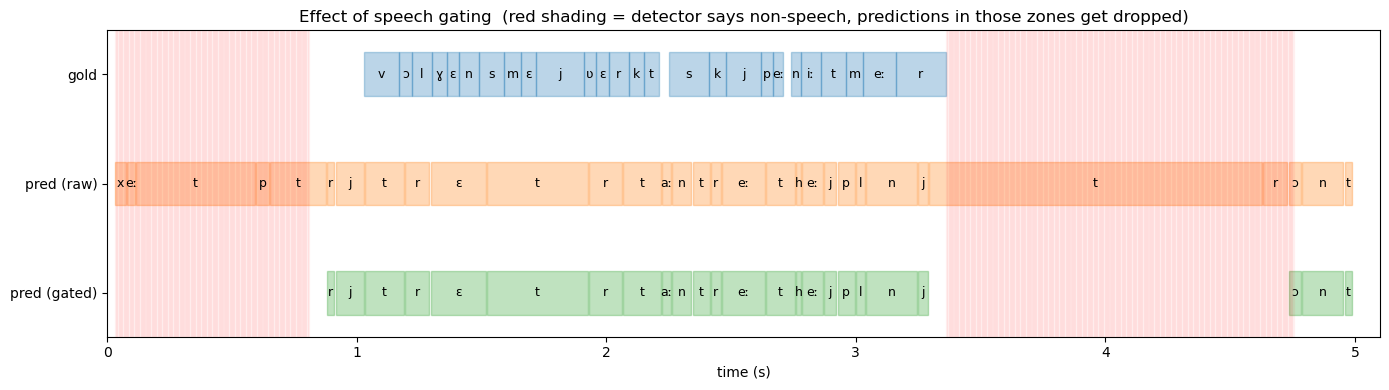

In [24]:
# Re-collapse Viterbi path, but now drop any segment whose majority is non-speech
SPEECH_FRAC_MIN = 0.5

# Align speech_mask to the stk index space (both use MO=5, SS=1 → same length)
mask_aligned = speech_mask[:len(path)] if len(speech_mask) >= len(path) else \
                np.concatenate([speech_mask,
                                np.zeros(len(path) - len(speech_mask), dtype=bool)])

pred_segments_gated = []
n_dropped = 0
i = 0
while i < len(path):
    ci, j = path[i], i + 1
    while j < len(path) and path[j] == ci: j += 1
    if (j - i) >= MIN_PRED_FRAMES:
        if mask_aligned[i:j].mean() >= SPEECH_FRAC_MIN:
            pred_segments_gated.append({
                'phone': class_labels[ci],
                'start_s': stk_frame_to_time_s(i),
                'end_s':   stk_frame_to_time_s(j - 1),
                'n_frames': j - i
            })
        else:
            n_dropped += 1
    i = j

print(f"Before gating: {len(pred_segments)} predicted segments")
print(f"After  gating: {len(pred_segments_gated)} predicted segments  "
      f"({n_dropped} dropped as silence)")
print(f"Gold reference: {len(mfa[SENT_IDX])} phonemes")

# Side-by-side: pre-gate vs post-gate vs gold
fig, ax = plt.subplots(figsize=(14, 4))
def draw_row(ax, segments, y, color, label, key='phone'):
    for s in segments:
        ax.add_patch(plt.Rectangle((s.get('start_s', s.get(1) if isinstance(s, (list, tuple)) else 0),
                                     y), s['end_s'] - s['start_s'], 0.4,
                                     color=color, alpha=0.3))
        ax.text((s['start_s'] + s['end_s'])/2, y + 0.2,
                s[key] if key in s else s['phone'],
                ha='center', va='center', fontsize=9)

# Gold
for ph in mfa[SENT_IDX]:
    ax.add_patch(plt.Rectangle((ph['start_s'], 2.0), ph['end_s']-ph['start_s'],
                                0.4, color='C0', alpha=0.3))
    ax.text((ph['start_s']+ph['end_s'])/2, 2.2, ph['phone'],
            ha='center', va='center', fontsize=9)
# Pred (ungated)
for s in pred_segments:
    ax.add_patch(plt.Rectangle((s['start_s'], 1.0), s['end_s']-s['start_s'],
                                0.4, color='C1', alpha=0.3))
    ax.text((s['start_s']+s['end_s'])/2, 1.2, s['phone'],
            ha='center', va='center', fontsize=9)
# Pred (gated)
for s in pred_segments_gated:
    ax.add_patch(plt.Rectangle((s['start_s'], 0.0), s['end_s']-s['start_s'],
                                0.4, color='C2', alpha=0.3))
    ax.text((s['start_s']+s['end_s'])/2, 0.2, s['phone'],
            ha='center', va='center', fontsize=9)

# Shade non-speech regions across the whole figure
for t in np.where(~mask_aligned)[0]:
    t0 = stk_frame_to_time_s(t)
    ax.axvspan(t0, t0 + SHIFT_S, color='red', alpha=0.04)

ax.set_xlim(0, t_stk[-1]); ax.set_ylim(-0.2, 2.6)
ax.set_yticks([0.2, 1.2, 2.2])
ax.set_yticklabels(['pred (gated)', 'pred (raw)', 'gold'])
ax.set_xlabel('time (s)')
ax.set_title(f'Effect of speech gating  '
             f'(red shading = detector says non-speech, predictions in those zones get dropped)')
plt.tight_layout(); plt.show()

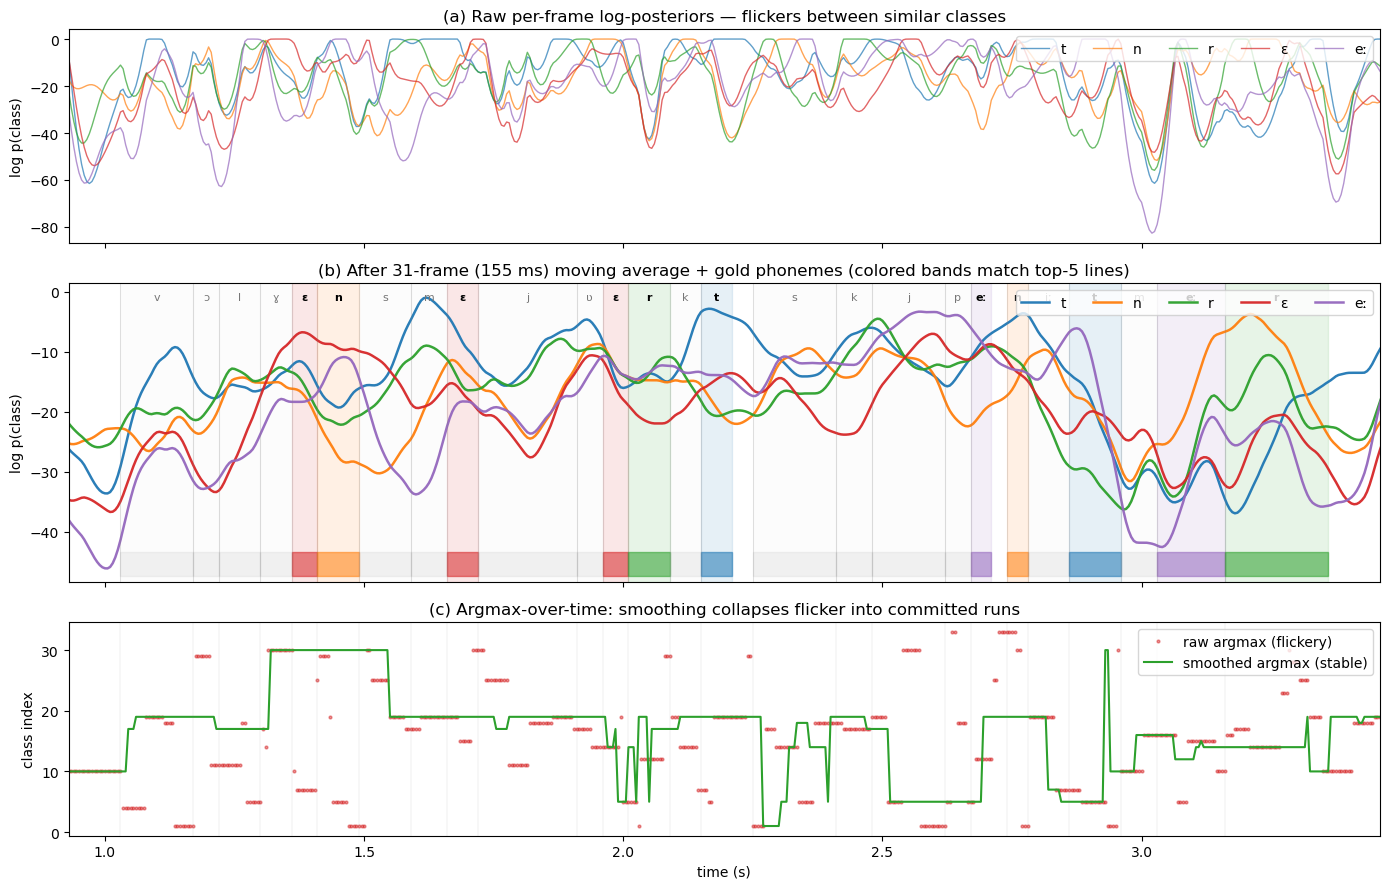

<Figure size 640x480 with 0 Axes>

Class transitions in raw argmax:      168
Class transitions in smoothed:         56
Reduction: 67%


In [25]:
# Compare raw vs smoothed log-probabilities for one slice of the sentence
# Pick top-5 classes by total predicted score, plot their per-frame log-prob over time

t_stk = np.arange(stk.shape[0]) * SHIFT_S + MARGIN * SHIFT_S
top5_idx = np.argsort(logp_raw.sum(axis=0))[-5:][::-1]
top5_labels = [class_labels[i] for i in top5_idx]
top5_colors = ['C0', 'C1', 'C2', 'C3', 'C4']
label_to_color = dict(zip(top5_labels, top5_colors))

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={'height_ratios': [1, 1.4, 1]})

# (a) Raw log-probs for top-5 classes
ax = axes[0]
for k, lbl, c in zip(top5_idx, top5_labels, top5_colors):
    ax.plot(t_stk, logp_raw[:, k], lw=1, alpha=0.7, color=c, label=lbl)
ax.set_ylabel('log p(class)')
ax.set_title('(a) Raw per-frame log-posteriors — flickers between similar classes')
ax.legend(loc='upper right', ncol=5)

# (b) Smoothed log-probs + gold-phoneme overlay
ax = axes[1]
for k, lbl, c in zip(top5_idx, top5_labels, top5_colors):
    ax.plot(t_stk, logp_smooth[:, k], lw=1.8, alpha=0.95, color=c, label=lbl)

# Determine vertical extent for the gold band (below the curves)
ymin, ymax = ax.get_ylim()
band_top    = ymin + 0.05 * (ymax - ymin)        # narrow band at the bottom
band_bottom = ymin - 0.02 * (ymax - ymin)

# Draw gold-phoneme regions
for ph in mfa[SENT_IDX]:
    color = label_to_color.get(ph['phone'], '#bbbbbb')
    alpha = 0.55 if ph['phone'] in top5_labels else 0.18
    # Background fill spanning the full y range, very light
    ax.axvspan(ph['start_s'], ph['end_s'], color=color, alpha=alpha*0.2,
                ymin=0, ymax=1)
    # Solid band at the bottom edge
    ax.axvspan(ph['start_s'], ph['end_s'], color=color, alpha=alpha,
                ymin=0.02, ymax=0.10)
    # Boundary lines
    ax.axvline(ph['start_s'], color='gray', lw=0.4, alpha=0.4)
    # Phoneme label at the top
    ax.text((ph['start_s'] + ph['end_s']) / 2, ymax - 0.03*(ymax-ymin),
            ph['phone'], ha='center', va='top', fontsize=8,
            color='black' if ph['phone'] in top5_labels else '#777',
            fontweight='bold' if ph['phone'] in top5_labels else 'normal')

# Reset y limits so the band sits inside the view
ax.set_ylim(ymin, ymax)
ax.set_ylabel('log p(class)')
ax.set_title(f'(b) After {SMOOTH_LOGP_W}-frame ({SMOOTH_LOGP_W*5} ms) moving average '
             f'+ gold phonemes (colored bands match top-5 lines)')
ax.legend(loc='upper right', ncol=5)

# (c) Argmax over time: raw vs smoothed
ax = axes[2]
argmax_raw    = logp_raw.argmax(axis=1)
argmax_smooth = logp_smooth.argmax(axis=1)
ax.plot(t_stk, argmax_raw,    'o', ms=2, color='C3', alpha=0.5, label='raw argmax (flickery)')
ax.plot(t_stk, argmax_smooth, '-', lw=1.5, color='C2', label='smoothed argmax (stable)')
# Mark gold-phoneme boundaries here too
for ph in mfa[SENT_IDX]:
    ax.axvline(ph['start_s'], color='gray', lw=0.3, alpha=0.3)
ax.set_ylabel('class index'); ax.set_xlabel('time (s)')
ax.set_title('(c) Argmax-over-time: smoothing collapses flicker into committed runs')
ax.legend(loc='upper right')
# Zoom to the gold phoneme range (with small padding)
gold_start = min(ph['start_s'] for ph in mfa[SENT_IDX])
gold_end   = max(ph['end_s']   for ph in mfa[SENT_IDX])
PAD = 0.1   # 100 ms padding on each side
xlim = (max(0, gold_start - PAD), gold_end + PAD)
for ax in axes:
    ax.set_xlim(xlim)
plt.tight_layout(); plt.show()

plt.tight_layout(); plt.show()

# Quantify the flicker reduction
def count_transitions(arr):
    return int(np.sum(np.diff(arr) != 0))

print(f"Class transitions in raw argmax:    {count_transitions(argmax_raw):>5}")
print(f"Class transitions in smoothed:      {count_transitions(argmax_smooth):>5}")
print(f"Reduction: {(1 - count_transitions(argmax_smooth)/max(count_transitions(argmax_raw),1))*100:.0f}%")

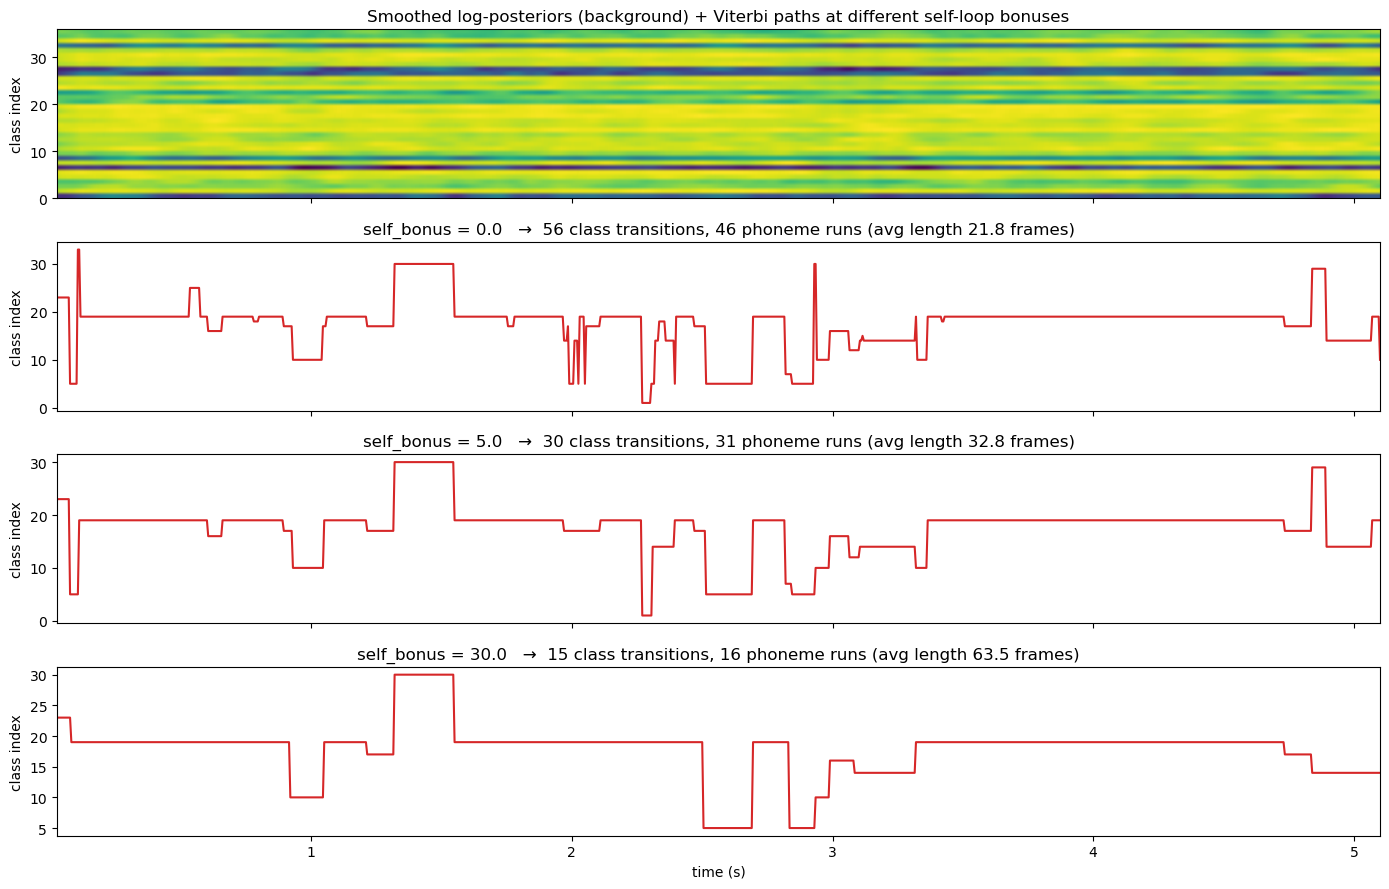

In [20]:
# Re-run Viterbi at 3 different bonus values to show the effect
paths = {b: viterbi_decode(logp_smooth, b) for b in [0.0, 5.0, 30.0]}

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

# (a) Heatmap of smoothed log-probs
ax = axes[0]
im = ax.imshow(logp_smooth.T, aspect='auto', origin='lower', cmap='viridis',
                extent=[t_stk[0], t_stk[-1], 0, logp_smooth.shape[1]])
ax.set_ylabel('class index')
ax.set_title('Smoothed log-posteriors (background) + Viterbi paths at different self-loop bonuses')

# (b-d) Viterbi path at each bonus value
for ax, b in zip(axes[1:], [0.0, 5.0, 30.0]):
    ax.plot(t_stk, paths[b], lw=1.5, color='C3')
    n_trans = count_transitions(paths[b])
    # Count runs ≥ MIN_PRED_FRAMES
    runs, i = [], 0
    while i < len(paths[b]):
        ci, j = paths[b][i], i + 1
        while j < len(paths[b]) and paths[b][j] == ci: j += 1
        if (j - i) >= MIN_PRED_FRAMES: runs.append(j - i)
        i = j
    ax.set_title(f'self_bonus = {b:.1f}   →  {n_trans} class transitions, '
                  f'{len(runs)} phoneme runs (avg length {np.mean(runs):.1f} frames)')
    ax.set_ylabel('class index')
axes[-1].set_xlabel('time (s)')

plt.tight_layout(); plt.show()

## Step 9 — Collapse into phoneme predictions

A "predicted phoneme" is a maximal run of consecutive frames with the same class.
The run's start time is the timestamp of the first frame; the end time is the
last. Short runs (<3 frames = <15 ms) are dropped as noise.

In [15]:
MIN_PRED_FRAMES = 3

def stk_frame_to_time_s(i):
    return ((i + MARGIN) * SHIFT_SAMP + WIN_SAMP / 2) / EEG_SR

class_labels = list(clf.classes_)
pred_segments = []
i = 0
while i < len(path):
    ci, j = path[i], i + 1
    while j < len(path) and path[j] == ci: j += 1
    if (j - i) >= MIN_PRED_FRAMES:
        pred_segments.append({
            'phone': class_labels[ci],
            'start_s': stk_frame_to_time_s(i),
            'end_s':   stk_frame_to_time_s(j - 1),
            'n_frames': j - i
        })
    i = j

print(f"Predicted {len(pred_segments)} phoneme segments")
print(f"Gold     {len(mfa[SENT_IDX])} phonemes")
print()
print(f"{'pred':>5}  {'start':>6}  {'end':>6}  {'n_fr':>4}")
for p in pred_segments[:15]:
    print(f"{p['phone']:>5}  {p['start_s']:>6.3f}  {p['end_s']:>6.3f}  {p['n_frames']:>4}")

Predicted 31 phoneme segments
Gold     26 phonemes

 pred   start     end  n_fr
    x   0.032   0.076    10
   eː   0.081   0.110     7
    t   0.115   0.593    99
    p   0.598   0.647    11
    t   0.652   0.876    47
    r   0.881   0.911     7
    j   0.916   1.028    24
    t   1.033   1.189    33
    r   1.194   1.292    21
    ɛ   1.296   1.516    46
    t   1.521   1.926    84
    r   1.931   2.063    28
    t   2.068   2.219    32
   aː   2.224   2.258     8
    n   2.263   2.341    17


## Step 10 — Compare to gold

Final view: side-by-side phoneme sequences, gold vs prediction. Cells with the
same phoneme at roughly the same time line up; mismatches and shifts are
visible at a glance.

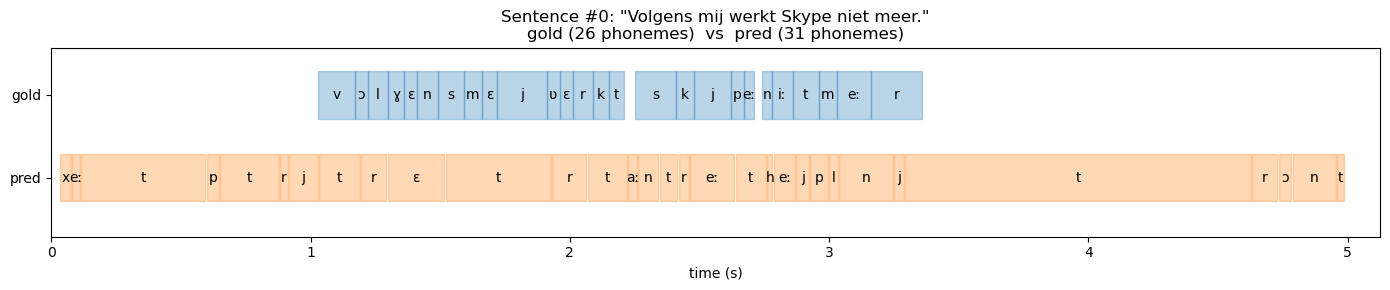


Length-3 contiguous matches (with ±3 shift): 0


In [16]:
gold = [(ph['phone'], ph['start_s'], ph['end_s']) for ph in mfa[SENT_IDX]]
pred = [(p['phone'],  p['start_s'],  p['end_s'])  for p in pred_segments]

fig, ax = plt.subplots(figsize=(14, 3))
for sym, t0, t1 in gold:
    ax.add_patch(plt.Rectangle((t0, 1.0), t1-t0, 0.4, color='C0', alpha=0.3))
    ax.text((t0+t1)/2, 1.2, sym, ha='center', va='center', fontsize=10)
for sym, t0, t1 in pred:
    ax.add_patch(plt.Rectangle((t0, 0.3), t1-t0, 0.4, color='C1', alpha=0.3))
    ax.text((t0+t1)/2, 0.5, sym, ha='center', va='center', fontsize=10)
ax.set_ylim(0, 1.6); ax.set_xlim(0, t_frames[-1])
ax.set_yticks([0.5, 1.2]); ax.set_yticklabels(['pred', 'gold'])
ax.set_xlabel('time (s)')
ax.set_title(f'Sentence #{SENT_IDX}: "{wd["sentence_list"][SENT_IDX]["text"]}"\n'
             f'gold ({len(gold)} phonemes)  vs  pred ({len(pred)} phonemes)')
plt.tight_layout(); plt.show()

# Exact match count (no shift tolerance for clarity here)
correct_3grams = 0
for i in range(len(pred) - 2):
    for j in range(len(gold) - 2):
        if abs(i - j) <= 3:    # shift tolerance
            if (pred[i][0], pred[i+1][0], pred[i+2][0]) == \
               (gold[j][0], gold[j+1][0], gold[j+2][0]):
                correct_3grams += 1
                break
print(f"\nLength-3 contiguous matches (with ±3 shift): {correct_3grams}")

## What this demo skips vs. the full pipeline

For clarity, the demo above leaves out:
- **Train / val / test split**. The real pipeline trains LDA on ~85% of
  training sentences and uses 15% to auto-tune the self-loop bonus.
- **Speech detector gating**. A separate trained model marks frames as
  speech/non-speech; predicted segments in non-speech windows are dropped.
- **Cross-band features**. The full pipeline can include LG amplitude,
  theta phase, and PAC terms in addition to HG amplitude.
- **Surprise-z scoring** with permutation null. The proper significance test
  shuffles predictions within sentences and compares the observed
  rarity-weighted match score to that null.

See `run_for_patient_sd` in the main notebook for the full pipeline including
all of the above.